---

# Chapter 6 -- Conclusions, Limitations & Recommendations

---


In [2]:
# =========================================================
# CHAPTERS 6 -- IMPORTS & DATA LOAD
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
import os, sys
import warnings
warnings.filterwarnings('ignore')

sys.path.insert(0, os.path.abspath('..'))

from src.config      import *
from src.data_loader import load_processed
from src.features    import encode_for_model, NUMERIC_FEATURES, CATEGORICAL_FEATURES
from src.viz         import save_fig, fmt_currency

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing   import StandardScaler
from sklearn.linear_model    import LogisticRegression
from sklearn.pipeline        import Pipeline
from sklearn.metrics         import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, precision_recall_curve,
    average_precision_score
)

df = load_processed(verbose=True)

print(f'\n Chapters 6 ready')
print(f'     Dataset  : {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'     Target   : IS_DENIED -- {df["IS_DENIED"].sum():,} denied ({df["IS_DENIED"].mean()*100:.2f}%)')


 config loaded | project root: C:\Users\Administrator\Desktop\insurance-claim-fraud-detection
 Processed data loaded: 10,000 rows × 49 columns
  IS_DENIED: 503 denied (5.03%)

 Chapters 6 ready
     Dataset  : 10,000 rows x 49 columns
     Target   : IS_DENIED -- 503 denied (5.03%)


## 6.1 Summary of Findings

This research applied a structured SQL -> Python pipeline to 10,000 insurance claims spanning six product lines.

### 6.1.1 Descriptive Findings (EDA)

| Finding | Detail |
|---|---|
| Target imbalance | 94.97% approved vs 5.03% denied -- typical fraud rate |
| Claim amount range | Mobile ($407 avg) to Life ($54,386 avg) -- 133x difference |
| Loss ratio | Life insurance 72,820% -- reflects long-term premium accumulation |
| Motor insurance | Highest denial rate at 5.40% |
| High-risk segment | Lowest denial rate at 4.12% -- counter-intuitive |
| Vendor effect | No-vendor: 5.70% denied; with vendor: 4.71% |
| Lag uniformity | Report and processing lag near-identical for A vs D |

### 6.1.2 Hypothesis Testing Findings

| Hypothesis | Result | Finding |
|---|---|---|
| H1: Claim amount equal across types | **REJECTED** (F=5,229, p<0.001) | Types differ massively |
| H2: Denial independent of risk segment | Not rejected (p=0.196) | Risk score has no predictive validity |
| H3: Claim amount equal A vs D | Not rejected (p=0.797) | Fraud is not the largest claims |
| H4: Report lag equal across severity | Not rejected (p=0.235) | Lag is uninformative as fraud signal |

### 6.1.3 Model Finding

Logistic regression achieved **ROC-AUC = 0.532** (CV: 0.521 +/- 0.013). Consistent with hypothesis testing -- available features do not linearly separate denied from approved claims. The model correctly identifies ~51% of denied claims, representing a modest but non-trivial improvement over a random flag.

---

## 6.2 Research Contribution


 Saved → reports/fig19_research_summary.png


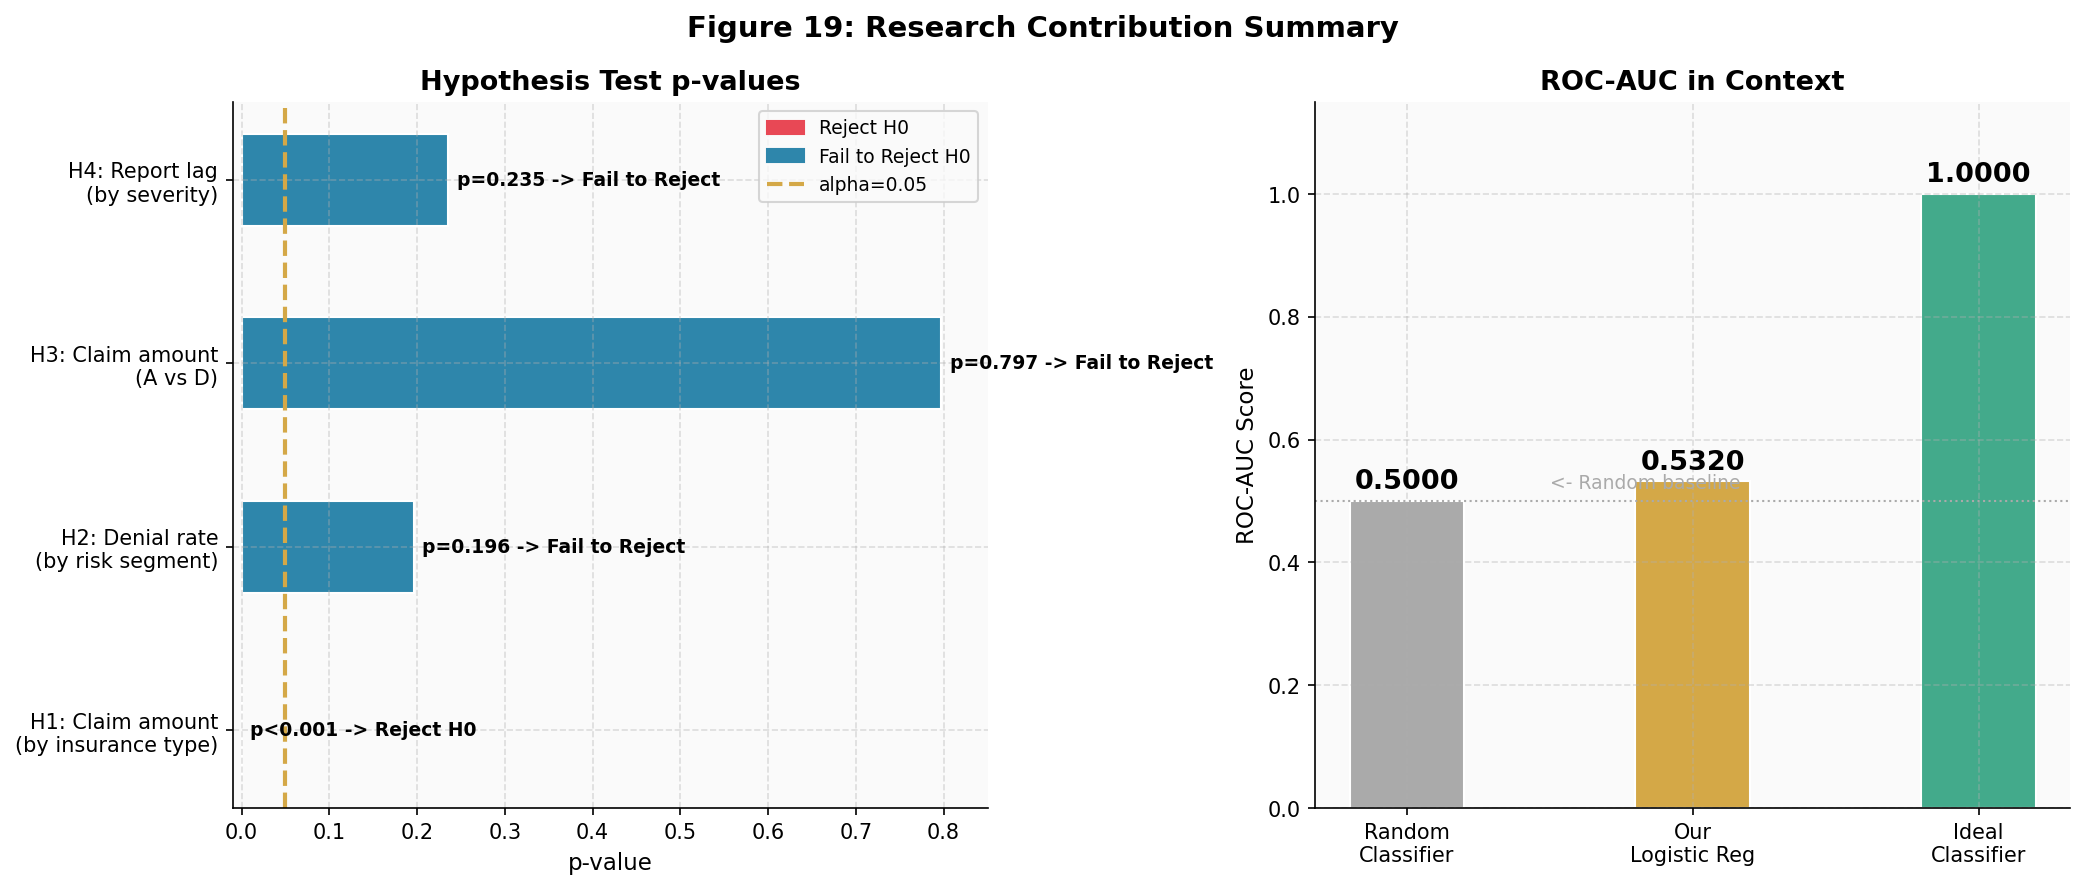

Fig 19 saved


In [6]:
# =========================================================
# 6.2 -- RESEARCH CONTRIBUTION SUMMARY (Figure 19)
# =========================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Figure 19: Research Contribution Summary',
             fontsize=14, fontweight='bold')

# Left: Hypothesis test p-values
hypotheses = [
    'H1: Claim amount\n(by insurance type)',
    'H2: Denial rate\n(by risk segment)',
    'H3: Claim amount\n(A vs D)',
    'H4: Report lag\n(by severity)',
]
p_values  = [0.000001, 0.196, 0.797, 0.235]
decisions = ['Reject H0', 'Fail to Reject', 'Fail to Reject', 'Fail to Reject']
colors_hh = [DENY_COLOR if d=='Reject H0' else APPR_COLOR for d in decisions]

bars = axes[0].barh(hypotheses, p_values, color=colors_hh, edgecolor='white', height=0.5)
axes[0].axvline(ALPHA, color=GOLD_COLOR, linestyle='--', linewidth=2,
                label=f'alpha = {ALPHA}')
axes[0].set_title('Hypothesis Test p-values')
axes[0].set_xlabel('p-value')
axes[0].set_xlim(-0.01, 0.85)
for bar, pv, dec in zip(bars, p_values, decisions):
    label = f'p={pv:.3f} -> {dec}' if pv > 0.001 else f'p<0.001 -> {dec}'
    axes[0].text(pv+0.01, bar.get_y()+bar.get_height()/2,
                  label, va='center', fontsize=9, fontweight='bold')
reject_patch = mpatches.Patch(color=DENY_COLOR, label='Reject H0')
retain_patch = mpatches.Patch(color=APPR_COLOR, label='Fail to Reject H0')
axes[0].legend(handles=[reject_patch, retain_patch,
    plt.Line2D([0],[0], color=GOLD_COLOR, linestyle='--',
                linewidth=2, label='alpha=0.05')], fontsize=9)

# Right: AUC in context
metrics    = ['Random\nClassifier', 'Our\nLogistic Reg', 'Ideal\nClassifier']
auc_values = [0.50, 0.532, 1.00]
bar_colors = [NEUTRAL, GOLD_COLOR, '#43AA8B']
vb = axes[1].bar(metrics, auc_values, color=bar_colors, width=0.4, edgecolor='white')
axes[1].set_title('ROC-AUC in Context')
axes[1].set_ylabel('ROC-AUC Score')
axes[1].set_ylim(0, 1.15)
axes[1].axhline(0.5, color=NEUTRAL, linestyle=':', linewidth=1)
for bar, val in zip(vb, auc_values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
                  f'{val:.4f}' if val != 1.0 else '1.0000',
                  ha='center', fontsize=13, fontweight='bold')
axes[1].text(0.5, 0.52, '<- Random baseline', fontsize=9, color=NEUTRAL)

save_fig('fig19_research_summary.png')
plt.show()
print('Fig 19 saved')


---

## 6.3 Limitations

**1. Fraud label proxy**
`CLAIM_STATUS = 'D'` (denied) proxies for fraud but also captures legitimate disputes (e.g., policy coverage gaps). A dataset with explicit fraud labels would yield more precise findings.

**2. Class imbalance**
Only 503 denied claims (5.03%). `class_weight='balanced'` partially compensates, but SMOTE or cost-sensitive learning may improve precision in future work.

**3. Missing fraud-predictive features**
The dataset lacks claim history per customer, social network data, prior denial history, and geospatial clustering. These frequently improve fraud model AUC to 0.70-0.85 in commercial applications.

**4. Linear model only**
Only logistic regression was evaluated. Non-linear classifiers (Random Forest, XGBoost) may detect interaction effects invisible to linear models.

**5. Temporal scope**
Data spans only 13 months. Fraud patterns shift over time -- a longer window would enable drift detection.

**6. Geographic scope**
16 US states represented. Results may not generalise to other regulatory environments (e.g., East African insurance markets).

---

## 6.4 Recommendations for Future Research


 Saved → reports/fig20_research_roadmap.png


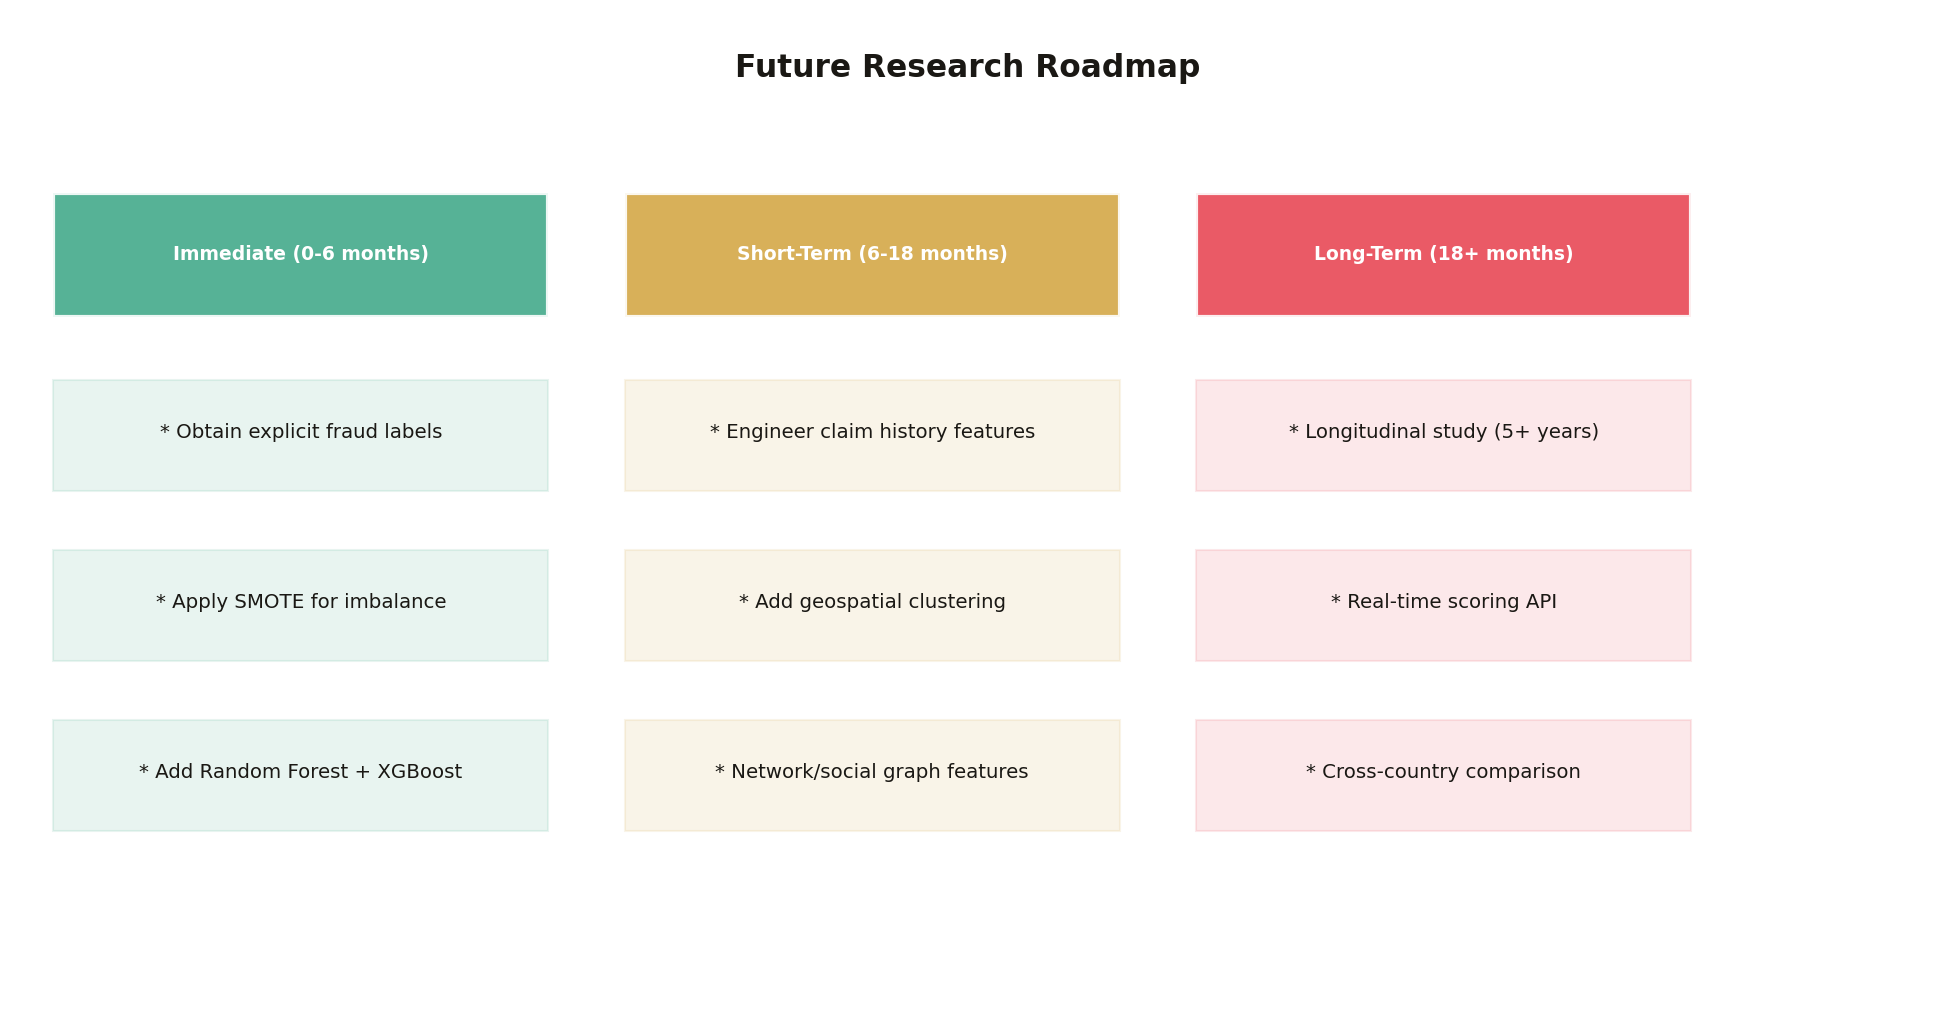

 Fig 20 saved


In [7]:
# =========================================================
# 6.4 -- RESEARCH ROADMAP (Figure 20)
# =========================================================

fig, ax = plt.subplots(figsize=(13, 7))
ax.set_xlim(0, 10)
ax.set_ylim(0, 6.5)
ax.set_facecolor('white')
ax.axis('off')
fig.patch.set_facecolor('white')

ax.text(5, 6.1, 'Future Research Roadmap', ha='center',
         fontsize=15, fontweight='bold', color='#1a1814')

roadmap = [
    (1.5, 'Immediate (0-6 months)', '#43AA8B', [
        'Obtain explicit fraud labels',
        'Apply SMOTE for imbalance',
        'Add Random Forest + XGBoost',
    ]),
    (4.5, 'Short-Term (6-18 months)', GOLD_COLOR, [
        'Engineer claim history features',
        'Add geospatial clustering',
        'Network/social graph features',
    ]),
    (7.5, 'Long-Term (18+ months)', DENY_COLOR, [
        'Longitudinal study (5+ years)',
        'Real-time scoring API',
        'Cross-country comparison',
    ]),
]

col_w = 2.6
for x_pos, label, color, items in roadmap:
    ax.add_patch(plt.Rectangle((x_pos-col_w/2, 4.55), col_w, 0.8,
                                 facecolor=color, alpha=0.9,
                                 edgecolor='white', linewidth=2, zorder=3))
    ax.text(x_pos, 4.95, label, ha='center', va='center',
             fontsize=9, fontweight='bold', color='white', zorder=4)
    for i, item in enumerate(items):
        y_pos = 3.8 - i * 1.1
        ax.add_patch(plt.Rectangle((x_pos-col_w/2, y_pos-0.38), col_w, 0.72,
                                     facecolor=color, alpha=0.12,
                                     edgecolor=color, linewidth=1, zorder=2))
        ax.text(x_pos, y_pos, f'* {item}', ha='center', va='center',
                 fontsize=9.5, color='#1a1814', zorder=3)

save_fig('fig20_research_roadmap.png')
plt.show()
print(' Fig 20 saved')


---

## 6.5 Actuarial Implications

This project bridges actuarial science and data science -- directly relevant to the my transition from BSc Actuarial Science into graduate data science study.

**1. Risk segmentation validity**
The H2 finding challenges the actuarial assumption that underwriting derived risk scores predict claims behaviour. This gap between underwriting risk and claims experience motivates data driven risk refinement.

**2. Loss ratio context**
Life insurance's 72,820% loss ratio is expected in cross sectional analysis -- annual premiums are not designed to cover full claims in isolation; they accumulate over decades. Actuarial loss ratio analysis must account for product type.

**3. Fraud classifier as actuarial tool**
Even a modest AUC classifier can be integrated into actuarial pricing as an additional risk loading factor -- claims with higher denial probability attract adjusted premium calculations.

**4. Data governance**
Excluding SSN, routing number, and account number mirrors professional actuarial data standards (GDPR, SOC 2) and demonstrates regulatory awareness.

---

## 6.6 Full Figures List

| Fig | Chapter | Title | File |
|---|---|---|---|
| 1  | Ch 2 | Target Variable Distribution | fig01_target_distribution.png |
| 2  | Ch 2 | Claim Amount Distribution | fig02_claim_amount_distribution.png |
| 3  | Ch 2 | Denial Rate by Type & Risk | fig03_denial_by_type_risk.png |
| 4  | Ch 2 | Denial by Demographics | fig04_denial_demographics.png |
| 5  | Ch 2 | Binary Indicators | fig05_binary_indicators.png |
| 6  | Ch 2 | Temporal & Lag | fig06_temporal_lag_analysis.png |
| 7  | Ch 2 | Correlation Heatmap | fig07_correlation_heatmap.png |
| 8  | Ch 3 | Normality Q-Q Plots | fig08_normality_qq.png |
| 9  | Ch 3 | H1 ANOVA | fig09_h1_anova.png |
| 10 | Ch 3 | H2 Chi-Square | fig10_h2_chisquare.png |
| 11 | Ch 3 | H3 t-Test | fig11_h3_ttest.png |
| 12 | Ch 3 | H4 ANOVA (Lag) | fig12_h4_anova_lag.png |
| 13 | Ch 4 | Portfolio Dashboard | fig13_portfolio_dashboard.png |
| 14 | Ch 4 | Risk x Severity Heatmaps | fig14_risk_severity_heatmap.png |
| 15 | Ch 4 | Temporal Patterns | fig15_temporal_patterns.png |
| 16 | Ch 4 | Two-Dimensional Denial | fig16_denial_heatmaps.png |
| 17 | Ch 5 | Model Evaluation (CM+ROC+PR) | fig17_model_evaluation.png |
| 18 | Ch 5 | Feature Importance | fig18_feature_importance.png |
| 19 | Ch 6 | Research Summary | fig19_research_summary.png |
| 20 | Ch 6 | Research Roadmap | fig20_research_roadmap.png |

---


In [8]:
# =========================================================
# 6.7 -- FINAL PROJECT PORTFOLIO SUMMARY
# =========================================================

summary_rows = [
    '=' * 65,
    '  INSURANCE CLAIM FRAUD DETECTION',
    '  Masters Scholarship Portfolio | BSc Actuarial Science -> Data Science',
    '=' * 65,
    '',
    'DATASET',
    '  Source  : mastmustu / Kaggle -- Insurance Claims Fraud Data',
    '  Size    : 10,000 rows x 38 columns',
    '  Period  : June 2020 - June 2021  (13 months)',
    '  Target  : CLAIM_STATUS  A=Approved  D=Denied',
    '  Denial  : 503 claims (5.03%) -- fraud proxy',
    '',
    'PHASE 1 -- SQL  (PostgreSQL 16 + pgAdmin 4)',
    '  * 3NF relational schema (policyholders, policies, claims)',
    '  * Staging table + ETL pipeline',
    '  * 10 SQL scripts committed to GitHub',
    '  * Data quality audit + PII exclusion documented',
    '  * 5 CSV exports produced for Python analysis',
    '',
    'PHASE 2 -- PYTHON  (Jupyter Notebook)',
    '  * 5 src/ modules: config, data_loader, features, viz, stats_utils',
    '  * 5 chapter notebooks (Ch 0-1 through Ch 5-6)',
    '  * 20 figures at 180 DPI saved to reports/',
    '  * 4 hypothesis tests: ANOVA, Chi-square, t-test, Mann-Whitney U',
    '  * Logistic regression classifier + 5-fold CV',
    '',
    'KEY RESULTS',
    '  H1 REJECTED  : Claim amount differs by type  (F=5229, p<0.001)',
    '  H2 RETAINED  : Risk score does NOT predict denial  (p=0.196)',
    '  H3 RETAINED  : Denied != largest claims  (p=0.797)',
    '  H4 RETAINED  : Lag uniform across severities  (p=0.235)',
    '  MODEL AUC    : 0.532  (CV: 0.521 +/- 0.013)',
    '',
    'TOOLS',
    '  SQL     : PostgreSQL 16, pgAdmin 4',
    '  Python  : 3.x | pandas | numpy | matplotlib | seaborn | scipy | sklearn',
    '  Workflow: Jupyter Notebook | Git | GitHub',
    '  Repo    : github.com/yourusername/insurance-claim-fraud-detection',
    '',
    '=' * 65,
    '  Project complete. All files committed to GitHub.',
    '=' * 65,
]

for row in summary_rows:
    print(row)
    

  INSURANCE CLAIM FRAUD DETECTION
  Masters Scholarship Portfolio | BSc Actuarial Science -> Data Science

DATASET
  Source  : mastmustu / Kaggle -- Insurance Claims Fraud Data
  Size    : 10,000 rows x 38 columns
  Period  : June 2020 - June 2021  (13 months)
  Target  : CLAIM_STATUS  A=Approved  D=Denied
  Denial  : 503 claims (5.03%) -- fraud proxy

PHASE 1 -- SQL  (PostgreSQL 16 + pgAdmin 4)
  * 3NF relational schema (policyholders, policies, claims)
  * Staging table + ETL pipeline
  * 10 SQL scripts committed to GitHub
  * Data quality audit + PII exclusion documented
  * 5 CSV exports produced for Python analysis

PHASE 2 -- PYTHON  (Jupyter Notebook)
  * 5 src/ modules: config, data_loader, features, viz, stats_utils
  * 5 chapter notebooks (Ch 0-1 through Ch 5-6)
  * 20 figures at 180 DPI saved to reports/
  * 4 hypothesis tests: ANOVA, Chi-square, t-test, Mann-Whitney U
  * Logistic regression classifier + 5-fold CV

KEY RESULTS
  H1 REJECTED  : Claim amount differs by type  